<a href="https://colab.research.google.com/github/ariel07-sw/angrist-evans-1998-iv-replication/blob/main/notebooks/Phase_3_The_Extension_%26_AI_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import os

os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/data/processed', exist_ok=True)

!mv /content/m_d_806.sas7bdat /content/data/raw/
!mv /content/m_d_903.sas7bdat /content/data/raw/

df_806 = pd.read_sas('/content/data/raw/m_d_806.sas7bdat')
df_903 = pd.read_sas('/content/data/raw/m_d_903.sas7bdat')

print(df_806.head())
print(df_903.head())

df_806.to_parquet('/content/data/processed/census80_cleaned.parquet', index=False)

   STATE  SEXK   AGEK QTRBKID  RACEK SPANISH BIRTHPLK SCHOOLK  GRADE FINGRADE  \
0  b'01'  b'1'  b'09'    b'3'  b'01'    b'0'   b'001'    b'1'  b'06'     b'1'   
1  b'01'  b'1'  b'08'    b'3'  b'01'    b'0'   b'001'    b'2'  b'05'     b'1'   
2  b'01'  b'0'  b'09'    b'1'  b'01'    b'0'   b'001'    b'1'  b'05'     b'1'   
3  b'01'  b'0'  b'05'    b'2'  b'01'    b'0'   b'001'    b'1'  b'02'     b'1'   
4  b'01'  b'1'  b'11'    b'1'  b'01'    b'0'   b'001'    b'1'  b'07'     b'1'   

   ... FINGRADD CLASSD WEEKSD HOURSD  INCOME1D  INCOME2D AWEEK79D  AHOUR79D  \
0  ...     b'2'   b'1'  b'52'  b'40'  b'28005'  b'00000'     b'0'      b'0'   
1  ...     b'2'   b'5'  b'52'  b'72'  b'00000'  b'10005'     b'0'      b'0'   
2  ...     b'2'   b'5'  b'16'  b'48'  b'00000'  b'16005'     b'0'      b'0'   
3  ...      NaN    NaN    NaN    NaN       NaN       NaN      NaN       NaN   
4  ...     b'2'   b'1'  b'32'  b'40'  b'09925'  b'00000'     b'0'      b'0'   

   AINC1D AINC2D  
0    b'0'   b'0'  


In [5]:
import pandas as pd
import numpy as np

def decode_bytes(x):
    if isinstance(x, bytes):
        return x.decode('utf-8').strip()
    return x

df_806 = df_806.applymap(decode_bytes)
df_903 = df_903.applymap(decode_bytes)

print(df_806.head())
print(df_903.head())

/tmp/ipykernel_40076/4017561122.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_806 = df_806.applymap(decode_bytes)
/tmp/ipykernel_40076/4017561122.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_903 = df_903.applymap(decode_bytes)


  STATE SEXK AGEK QTRBKID RACEK SPANISH BIRTHPLK SCHOOLK GRADE FINGRADE  ...  \
0    01    1   09       3    01       0      001       1    06        1  ...   
1    01    1   08       3    01       0      001       2    05        1  ...   
2    01    0   09       1    01       0      001       1    05        1  ...   
3    01    0   05       2    01       0      001       1    02        1  ...   
4    01    1   11       1    01       0      001       1    07        1  ...   

  FINGRADD CLASSD WEEKSD HOURSD INCOME1D INCOME2D AWEEK79D  AHOUR79D  AINC1D  \
0        2      1     52     40    28005    00000        0         0       0   
1        2      5     52     72    00000    10005        0         0       0   
2        2      5     16     48    00000    16005        0         0       2   
3      NaN    NaN    NaN    NaN      NaN      NaN      NaN       NaN     NaN   
4        2      1     32     40    09925    00000        0         0       3   

  AINC2D  
0      0  
1      3  
2    

In [6]:
for col in df_806.columns:
    df_806[col] = pd.to_numeric(df_806[col], errors='ignore')

for col in df_903.columns:
    df_903[col] = pd.to_numeric(df_903[col], errors='ignore')

print(df_806.dtypes.head(20))
print(df_903.dtypes.head(20))

/tmp/ipykernel_40076/665927078.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_806[col] = pd.to_numeric(df_806[col], errors='ignore')
/tmp/ipykernel_40076/665927078.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_903[col] = pd.to_numeric(df_903[col], errors='ignore')


STATE         int64
SEXK          int64
AGEK          int64
QTRBKID       int64
RACEK         int64
SPANISH       int64
BIRTHPLK      int64
SCHOOLK       int64
GRADE         int64
FINGRADE      int64
ASEX          int64
AAGE          int64
AQTRBRTH      int64
ABIRTHPL      int64
ASCHOOL       int64
AYEARSCH      int64
AFINGRAD      int64
YOBK        float64
AGEQK       float64
SEX2ND      float64
dtype: object
SEX2NDK     float64
MULTI2ND    float64
AGE2NDK     float64
ASEX2ND     float64
AAGE2ND     float64
SEXK          int64
RACEK         int64
AGEK        float64
PWGTK1      float64
HISPK         int64
BIRTHPLK      int64
SCHOOLK       int64
YEARSCHK      int64
ASEX          int64
ARACE         int64
AAGE          int64
ABIRTHPL      int64
ASCHOOL       int64
AYEARSCL      int64
YOBK        float64
dtype: object


In [7]:
print(df_806.columns.tolist())

['STATE', 'SEXK', 'AGEK', 'QTRBKID', 'RACEK', 'SPANISH', 'BIRTHPLK', 'SCHOOLK', 'GRADE', 'FINGRADE', 'ASEX', 'AAGE', 'AQTRBRTH', 'ABIRTHPL', 'ASCHOOL', 'AYEARSCH', 'AFINGRAD', 'YOBK', 'AGEQK', 'SEX2ND', 'RACE2ND', 'SPAN2ND', 'SCH2ND', 'GRADE2ND', 'FIN2ND', 'ASEX2ND', 'AAGE2ND', 'AQTR2ND', 'ASCH2ND', 'AYEAR2ND', 'AFIN2ND', 'AGEQ2ND', 'SEX3RD', 'AGEQ3RD', 'SEX4TH', 'AGEQ4TH', 'SEX5TH', 'AGEQ5TH', 'TWIN1ST', 'TRIPLET', 'KIDCOUNT', 'FAMINC', 'AGEM', 'QTRBTHM', 'MARITAL', 'RACEM', 'SPANISHM', 'FERT', 'TIMESMAR', 'AGEMAR', 'QTRMAR', 'WIDOW', 'GRADEM', 'FINGRADM', 'CLASSM', 'WEEKSM', 'HOURSM', 'INCOME1M', 'INCOME2M', 'INCOME6M', 'POVERTY', 'AFERTIL', 'AWEEK79M', 'AHOUR79M', 'AINC1M', 'AINC2M', 'YOBM', 'AGED', 'QTRBTHD', 'RACED', 'SPANISHD', 'TIMEMARD', 'AGEMARD', 'QTRMARD', 'GRADED', 'FINGRADD', 'CLASSD', 'WEEKSD', 'HOURSD', 'INCOME1D', 'INCOME2D', 'AWEEK79D', 'AHOUR79D', 'AINC1D', 'AINC2D']


In [8]:
print(df_806[['SEXK', 'AGEK', 'RACEK', 'GRADE', 'WEEKSD', 'HOURSD']].head(10))

   SEXK  AGEK  RACEK  GRADE  WEEKSD  HOURSD
0     1     9      1      6    52.0    40.0
1     1     8      1      5    52.0    72.0
2     0     9      1      5    16.0    48.0
3     0     5      1      2     NaN     NaN
4     1    11      1      7    32.0    40.0
5     0     6      1      0    52.0    40.0
6     0     2      1      0    20.0    40.0
7     0     3      1      0    48.0    40.0
8     0     2      2      0    52.0    40.0
9     1    15      1     12    52.0    40.0


In [9]:
print([c for c in df_806.columns if '2ND' in c.upper()])

['SEX2ND', 'RACE2ND', 'SPAN2ND', 'SCH2ND', 'GRADE2ND', 'FIN2ND', 'ASEX2ND', 'AAGE2ND', 'AQTR2ND', 'ASCH2ND', 'AYEAR2ND', 'AFIN2ND', 'AGEQ2ND']


In [10]:
print(df_806['GRADEM'].value_counts(dropna=False).sort_index())
print(df_806['FINGRADM'].value_counts(dropna=False).sort_index())

GRADEM
0       2402
1         31
2         90
3        443
4        973
5       1738
6       2621
7       2840
8       8057
9       5695
10     18341
11     26154
12     45016
13     46397
14    423936
15     89685
16     81923
17     33946
18     82165
19     26787
20     17394
21      4213
22      6420
Name: count, dtype: int64
FINGRADM
0      2402
1     51366
2    751981
3    121518
Name: count, dtype: int64


In [11]:
print(df_806[['GRADEM', 'FINGRADM']].head(20))

    GRADEM  FINGRADM
0       14         2
1       17         2
2       14         2
3       14         2
4       10         3
5       14         2
6       10         3
7       14         2
8       14         2
9       14         2
10      16         2
11      14         2
12      14         2
13       9         2
14      17         3
15      14         2
16      14         2
17      12         2
18      14         2
19      15         1


In [12]:
import numpy as np
import pandas as pd

df_806['same_sex'] = (df_806['SEXK'] == df_806['SEX2ND']).astype(int)

df_806['more_than_2'] = (df_806['KIDCOUNT'] > 2).astype(int)

df_806['worked_m'] = ((df_806['WEEKSM'].fillna(0) > 0) | (df_806['HOURSM'].fillna(0) > 0)).astype(int)

df_806['AGEM_sq'] = df_806['AGEM'] ** 2

df_806['high_edu'] = (df_806['GRADEM'] >= 15).astype(int)
df_806['low_edu'] = (df_806['GRADEM'] <= 14).astype(int)

print(df_806[['GRADEM', 'high_edu', 'low_edu']].head(20))
print(df_806['high_edu'].value_counts(dropna=False))

    GRADEM  high_edu  low_edu
0       14         0        1
1       17         1        0
2       14         0        1
3       14         0        1
4       10         0        1
5       14         0        1
6       10         0        1
7       14         0        1
8       14         0        1
9       14         0        1
10      16         1        0
11      14         0        1
12      14         0        1
13       9         0        1
14      17         1        0
15      14         0        1
16      14         0        1
17      12         0        1
18      14         0        1
19      15         1        0
high_edu
0    584734
1    342533
Name: count, dtype: int64


In [13]:
vars_needed = [
    'worked_m',
    'WEEKSM',
    'HOURSM',
    'more_than_2',
    'same_sex',
    'AGEM',
    'AGEM_sq',
    'RACEM',
    'STATE',
    'AGEK',
    'SEXK',
    'SEX2ND',
    'GRADEM',
    'high_edu'
]

df_iv = df_806[vars_needed].copy()
df_iv = df_iv.dropna()

print(df_iv.shape)
df_iv.head()

(655169, 14)


,worked_m,WEEKSM,HOURSM,more_than_2,same_sex,AGEM,AGEM_sq,RACEM,STATE,AGEK,SEXK,SEX2ND,GRADEM,high_edu
0,1,16,30,0,0,36,1296,1,1,9,1,0.0,14,0
2,0,0,0,0,0,27,729,1,1,9,0,1.0,14,0
3,1,52,38,0,0,25,625,1,1,5,0,1.0,14,0
4,1,30,40,0,0,30,900,1,1,11,1,0.0,10,0
5,0,0,0,0,0,27,729,1,1,6,0,1.0,14,0


In [14]:
df_low = df_iv[df_iv['high_edu'] == 0].copy()
df_high = df_iv[df_iv['high_edu'] == 1].copy()

print("Low education:", df_low.shape)
print("High education:", df_high.shape)

Low education: (420006, 14)
High education: (235163, 14)


In [15]:
from linearmodels.iv import IV2SLS

In [16]:
from linearmodels.iv import IV2SLS

formula_weeks = '''
WEEKSM ~ 1
+ AGEM + AGEM_sq
+ C(RACEM) + C(STATE)
+ AGEK
+ SEXK + SEX2ND
[more_than_2 ~ same_sex]
'''

In [18]:
iv_low_weeks = IV2SLS.from_formula(formula_weeks, data=df_low).fit(cov_type='robust')
print(iv_low_weeks.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                 WEEKSM   R-squared:                      0.0883
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0881
No. Observations:              420006   F-statistic:                 3.209e+04
Date:                Wed, Mar 25 2026   P-value (F-stat)                0.0000
Time:                        19:59:45   Distribution:                 chi2(68)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept         -11.318     0.8026    -14.102     0.0000     -12.891     -9.7445
AGEM               1.3519     0.0492

In [19]:
iv_high_weeks = IV2SLS.from_formula(formula_weeks, data=df_high).fit(cov_type='robust')
print(iv_high_weeks.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                 WEEKSM   R-squared:                      0.0766
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0763
No. Observations:              235163   F-statistic:                 1.951e+04
Date:                Wed, Mar 25 2026   P-value (F-stat)                0.0000
Time:                        20:00:35   Distribution:                 chi2(68)
Cov. Estimator:                robust                                         
                                                                              
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept          3.7946     1.5268     2.4852     0.0129      0.8020      6.7871
AGEM               0.6385     0.0894

In [20]:
coef_low_w = iv_low_weeks.params['more_than_2']
se_low_w = iv_low_weeks.std_errors['more_than_2']

coef_high_w = iv_high_weeks.params['more_than_2']
se_high_w = iv_high_weeks.std_errors['more_than_2']

print("Low education:")
print("coef =", coef_low_w)
print("se =", se_low_w)
print("95% CI =", (coef_low_w - 1.96*se_low_w, coef_low_w + 1.96*se_low_w))

print("\nHigh education:")
print("coef =", coef_high_w)
print("se =", se_high_w)
print("95% CI =", (coef_high_w - 1.96*se_high_w, coef_high_w + 1.96*se_high_w))

Low education:
coef = -5.87888222618844
se = 1.148477291799255
95% CI = (np.float64(-8.12989771811498), np.float64(-3.6278667342619006))

High education:
coef = -1.2529691863156294
se = 1.6492173158588344
95% CI = (np.float64(-4.485435125398945), np.float64(1.979496752767686))


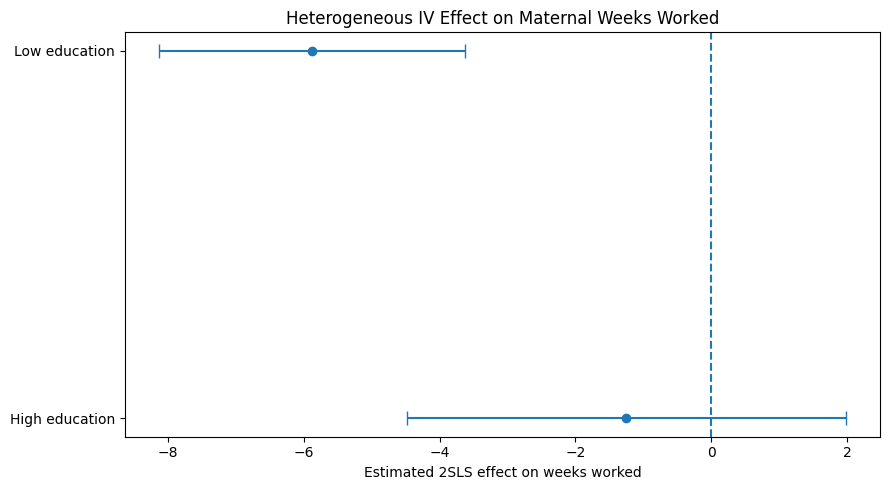

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_weeks = pd.DataFrame({
    'Group': ['Low education', 'High education'],
    'Estimate': [coef_low_w, coef_high_w],
    'Conf_Int_Lower': [coef_low_w - 1.96*se_low_w, coef_high_w - 1.96*se_high_w],
    'Conf_Int_Upper': [coef_low_w + 1.96*se_low_w, coef_high_w + 1.96*se_high_w]
})

plot_df = results_weeks.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(plot_df))
xerr_left = plot_df['Estimate'] - plot_df['Conf_Int_Lower']
xerr_right = plot_df['Conf_Int_Upper'] - plot_df['Estimate']

ax.errorbar(
    plot_df['Estimate'],
    y_pos,
    xerr=[xerr_left, xerr_right],
    fmt='o',
    capsize=5
)

ax.axvline(0, linestyle='--')
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Group'])
ax.set_xlabel('Estimated 2SLS effect on weeks worked')
ax.set_title('Heterogeneous IV Effect on Maternal Weeks Worked')

plt.tight_layout()
plt.show()

The Pathway 2 results show clear heterogeneity by maternal education. For lower-education mothers, having more than two children significantly reduces both employment probability and weeks worked. For higher-education mothers, the estimated effects are much closer to zero and statistically insignificant. This suggests that the labor-supply cost of an additional child is not uniform across mothers, but is concentrated among the lower-education group.


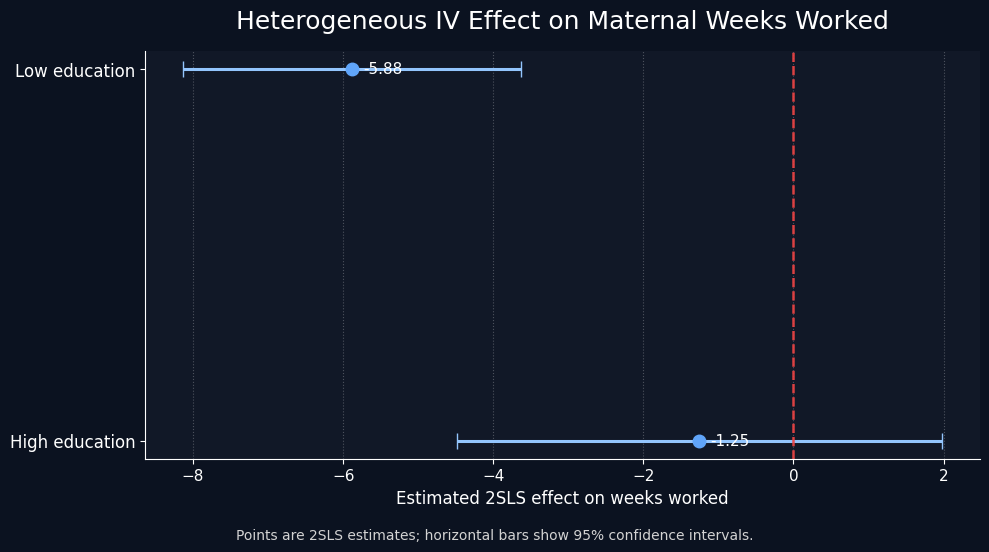

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 整理结果
results_df = pd.DataFrame({
    'Group': ['Low education', 'High education'],
    'Estimate': [coef_low_w, coef_high_w],
    'Conf_Int_Lower': [coef_low_w - 1.96 * se_low_w, coef_high_w - 1.96 * se_high_w],
    'Conf_Int_Upper': [coef_low_w + 1.96 * se_low_w, coef_high_w + 1.96 * se_high_w]
})

# 让 Low education 显示在上面
plot_df = results_df.iloc[::-1].reset_index(drop=True)

# 2. 画图
fig, ax = plt.subplots(figsize=(10, 5.5))

# Dark theme
bg_color = '#0b1220'
panel_color = '#111827'
text_color = 'white'
point_color = '#60a5fa'
line_color = '#93c5fd'
zero_line_color = '#ef4444'

fig.patch.set_facecolor(bg_color)
ax.set_facecolor(panel_color)

y_pos = np.arange(len(plot_df))

xerr_left = plot_df['Estimate'] - plot_df['Conf_Int_Lower']
xerr_right = plot_df['Conf_Int_Upper'] - plot_df['Estimate']

ax.errorbar(
    plot_df['Estimate'],
    y_pos,
    xerr=[xerr_left, xerr_right],
    fmt='o',
    color=point_color,
    ecolor=line_color,
    elinewidth=2.2,
    capsize=6,
    markersize=9,
    markerfacecolor=point_color,
    markeredgecolor=point_color
)

# x=0 参考线
ax.axvline(0, color=zero_line_color, linestyle='--', linewidth=1.8, alpha=0.9)

# 轴标签
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Group'], fontsize=12, color=text_color)
ax.set_xlabel('Estimated 2SLS effect on weeks worked', fontsize=12, color=text_color)
ax.set_title('Heterogeneous IV Effect on Maternal Weeks Worked', fontsize=18, color=text_color, pad=16)

# 网格线
ax.grid(axis='x', linestyle=':', alpha=0.25, color='white')
ax.grid(axis='y', visible=False)

# 美化边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

ax.tick_params(axis='x', colors=text_color, labelsize=11)
ax.tick_params(axis='y', colors=text_color, labelsize=12)

# 给点加数值标签
for i, row in plot_df.iterrows():
    ax.text(
        row['Estimate'] + 0.15,
        i,
        f"{row['Estimate']:.2f}",
        va='center',
        ha='left',
        fontsize=11,
        color=text_color
    )

# 图注
caption = "Points are 2SLS estimates; horizontal bars show 95% confidence intervals."
fig.text(0.5, 0.01, caption, ha='center', fontsize=10, color='lightgray')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# 3. 导出高清图片
fig.savefig('/content/iv_forest_plot_weeks.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())